In [1]:
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from config_plot import *
from generators import PoissonSpikeGenerator

In [2]:
generator = PoissonSpikeGenerator(
    baseline_fr=10,
    response_fr=10,
    latency=0.25,
    duration=0.1,
    baseline_T=1,
    stimulus_T=1,
    dt=0.001,
    induce_refractory_period=False
)

trial_activity = generator.generate_trials(1000)

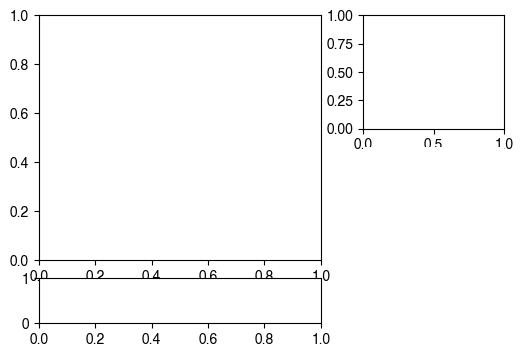

In [14]:
fig, axes = plt.subplot_mosaic(
    [
        ["raster", "isi"],
        ["raster", "text"],
        ["r_t", "empty"]
    ], 
    empty_sentinel="empty", 
    width_ratios=[2, 1],
    height_ratios=[1,1,0.4],
    figsize=(6,4),
)

ax = axes["raster"]


ax = axes["isi"]


ax = axes["r_t"]


ax = axes["text"]

ax.set_xticks([])
ax.set_yticks([])

sns.despine(left=True, bottom=True, ax=ax)

plt.show()





In [ ]:
baseline_bins = [0, baseline_T] # count spikes during entire baseline period, already in Hz
baseline_hist = np.array([np.histogram(trial, baseline_bins)[0] for trial in trial_activity]).ravel()
assert sum(baseline_hist) == sum([sum(t <= 1) for t in trial_activity]), "Binned baseline spikes do not match number of baseline spikes."

# interleave
bin_width = 0.1

bins_straight_up = np.arange(baseline_T, (baseline_T + stimulus_T)+bin_width, bin_width)
bins_betweeners = np.arange(baseline_T+(bin_width/2), (baseline_T + stimulus_T), bin_width)

# bin data, spike count / 100 ms
hist_straight_up = np.array([np.histogram(trial, bins_straight_up)[0] for trial in trial_activity])
hist_betweeners = np.array([np.histogram(trial, bins_betweeners)[0] for trial in trial_activity])

assert hist_straight_up.sum() == sum([sum(t > 1) for t in trial_activity]), "Binned stimulus spikes (full period) do not match number of total stimulus spikes."
lower = baseline_T + bin_width/2
upper = baseline_T + stimulus_T - bin_width/2
assert (hist_betweeners).sum() == sum([sum((t > lower) & (t < upper)) for t in trial_activity]), "Binned stimulus spikes (interleaved period) do not match number of total stimulus spikes."

interleaved = np.zeros((len(trial_activity), len(bins_straight_up)+len(bins_betweeners)-2), int)
interleaved[:, ::2] = hist_straight_up
interleaved[:, 1::2] = hist_betweeners
assert interleaved.sum() == hist_betweeners.sum() + hist_straight_up.sum(), "Interleaved matrix does not included the expected number of spikes."

# convert to rate per second, from rate per (bin width)
interleaved = interleaved * stimulus_T / bin_width



proportion_active = (1/3)
direction="positive"



n_bins = interleaved.shape[1]
n_trials = interleaved.shape[0]


atrials = interleaved.any(1).sum()

pvals_binwise = np.ones(n_bins)
direction_of_bin = np.zeros(n_bins, dtype=bool)

# count number of spikes in baseline for determining response direction
baseline_sum = baseline_hist.sum()

if atrials > n_trials * proportion_active:
    
    
    for bin_i in range(n_bins):
        if (baseline_hist - interleaved[:, bin_i]).any():
            _, pval = wilcoxon(interleaved[:, bin_i], baseline_hist)
        
        elif not (baseline_hist - interleaved[:, bin_i]).any():
            pval = -1
        
        direction_of_bin[bin_i] = interleaved[:, bin_i].sum() >= baseline_sum

        pvals_binwise[bin_i] = pval

    # restrict response search based on the direction of the response
    # by forcing bins with conflicting direction to have a value of 1.
    pvals_binwise[~direction_of_bin] = 1
    
    # apply Simes 
    pvals_binwise.sort()
    pvals_binwise *=  n_bins / np.arange(1, n_bins + 1)

pval_abs = np.abs(pvals_binwise)

pval_surviving = pval_abs.min()
print("surviving pval", pval_surviving)


0.5625 7 10.0
0.5625 7 10.0
0.125 7 0.0
0.875 7 10.0
0.875 7 20.0
0.875 7 20.0
0.875 7 10.0
0.75 7 20.0
0.75 7 20.0
0.125 7 0.0
0.875 7 20.0
0.875 7 20.0
0.5625 7 10.0
1.0 7 20.0
0.5625 7 10.0
0.5625 7 10.0
0.5625 7 10.0
0.125 7 0.0
0.125 7 0.0
surviving pval 1.0


In [11]:
n_trials = 10
n_units = 100


pval_collection = []

for u in tqdm(range(n_units)):
    trial_activity = [generate_trial(baseline_T, stimulus_T, dt, rate_fxn, ) for i in range(n_trials)]
    baseline_bins = [0, baseline_T] # count spikes during entire baseline period, already in Hz
    baseline_hist = np.array([np.histogram(trial, baseline_bins)[0] for trial in trial_activity]).ravel()

    # interleave
    bin_width = 0.1

    interleave_straight_up = np.arange(baseline_T, (baseline_T + stimulus_T)+bin_width, bin_width)
    interleave_betweeners = np.arange(baseline_T+(bin_width/2), (baseline_T + stimulus_T), bin_width)

    # bin data, spike count / 100 ms
    hist_straight_up = np.array([np.histogram(trial, interleave_straight_up)[0] for trial in trial_activity])
    hist_betweeners = np.array([np.histogram(trial, interleave_betweeners)[0] for trial in trial_activity])

    interleaved = np.zeros((len(trial_activity), len(interleave_straight_up)+len(interleave_betweeners)-2), int)
    interleaved[:, ::2] = hist_straight_up
    interleaved[:, 1::2] = hist_betweeners

    # convert to Hz (multiply by 10)
    interleaved = interleaved / bin_width



    proportion_active = (1/3)

    n_bins = interleaved.shape[1]

    direction="positive"

    atrials = interleaved.any(1).sum()

    pvals_binwise = np.ones(interleaved.shape[1])
    direction_of_bin = np.zeros(interleaved.shape[1], dtype=bool)

    # count number of spikes in baseline for determining response direction
    baseline_sum = baseline_hist.sum()

    if atrials > interleaved.shape[0] * proportion_active:
        
        
        for bin_i in range(n_bins):
            if (baseline_hist - interleaved[:, bin_i]).any():
                _, pval = wilcoxon(interleaved[:, bin_i], baseline_hist)
                #print(pval,baseline_sum, interleaved[:, bin_i].sum())
            
            elif not (baseline_hist - interleaved[:, bin_i]).any():
                pval = -1
            
            direction_of_bin[bin_i] = interleaved[:, bin_i].sum() >= baseline_sum

            pvals_binwise[bin_i] = pval
        pvals_binwise[~direction_of_bin] = 1
        
        pvals_binwise.sort()
        pvals_binwise *=  n_bins / np.arange(1, n_bins + 1)

    pval_abs = np.abs(pvals_binwise)

    pval_surviving = pval_abs.min()
    pval_collection.append(pval_surviving)

100%|██████████| 100/100 [03:37<00:00,  2.17s/it]


In [ ]:
pval_collection 

[np.float64(1.0),
 np.float64(1.0),
 np.float64(0.853515625),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.66796875),
 np.float64(1.0),
 np.float64(0.857638888888889),
 np.float64(0.7916666666666667),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.6927083333333333),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.8411458333333333),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.81640625),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.9236111111111112),
 np.float64(1.0),
 np.float64(0.96484375),
 np.float64(0.857638888888889),
 np.float64(1.0),
 np.float64(0.9715909090909091),
 np.float64(0.4453125),
 np.float64(1.0),
 np.float64(0.890625),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.7556818181818182),
 np.float64(1.0),
 np.float64(0.9330357142857143),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),

(array([ 1.,  0.,  1.,  0.,  0.,  2.,  0.,  0.,  5.,  1.,  0.,  2.,  1.,
         3.,  5.,  1.,  1.,  6.,  2., 69.]),
 array([0.4453125 , 0.47304687, 0.50078125, 0.52851563, 0.55625   ,
        0.58398438, 0.61171875, 0.63945312, 0.6671875 , 0.69492188,
        0.72265625, 0.75039062, 0.778125  , 0.80585938, 0.83359375,
        0.86132812, 0.8890625 , 0.91679687, 0.94453125, 0.97226563,
        1.        ]),
 <BarContainer object of 20 artists>)

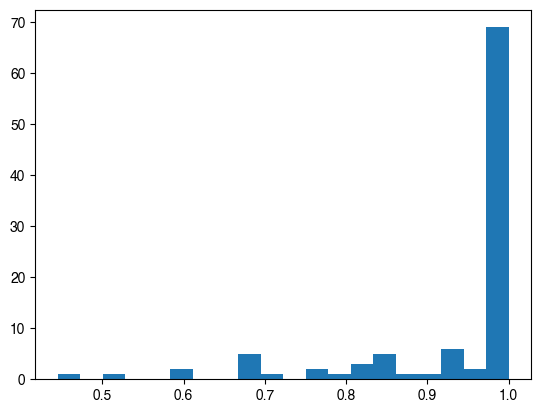

In [12]:
plt.hist(pval_collection, bins=20)